# Forecast Classification: Previsão de Direção das Vendas Diárias

*Forecasting* clássico prediz o **valor** futuro de uma série temporal. Em **Forecast Classification**, convertemos o problema de previsão em um problema de **classificação**: em vez de estimar a quantidade de amanhã, perguntamos *"a venda de amanhã vai ser maior ou menor que a de hoje?"*.

Neste notebook usamos dados reais de vendas (dataset `fato_vendas.parquet` do projeto *sales-forecast*, ~6,5M transações de 2022) e:

- Agregamos em série diária de quantidade vendida
- Construímos features de janela deslizante (lags, médias, desvios, tendência) + calendário
- Definimos alvo binário: **subiu (1)** vs **caiu (0)**
- Comparamos 4 modelos (Logística, Random Forest, XGBoost, LightGBM) com validação temporal
- Comparamos contra baselines (maioria, persistência)

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Carregamento do dataset real

`fato_vendas.parquet` contém transações de vendas (2022-01-01 a 2022-12-31). Vamos agregar a coluna `quantity` por dia.

In [2]:
candidates = [
    'fato_vendas.parquet',
    '../../sales-forecast/data/raw/fato_vendas.parquet',
    'D:/mlops-experiments/experiments/sales-forecast/data/raw/fato_vendas.parquet',
]
DATA_PATH = next(p for p in candidates if os.path.exists(p))
print('Dataset:', DATA_PATH)

df = pd.read_parquet(DATA_PATH, columns=['transaction_date', 'quantity'])
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print('Transações:', len(df), '| período:', df['transaction_date'].min().date(), '→', df['transaction_date'].max().date())

s = df.groupby('transaction_date')['quantity'].sum().sort_index()
s = s.replace(0, np.nan).interpolate().bfill()

# Winsorização: corta outliers extremos no P99 (a série tem um pico catastrófico em 11/set)
s = s.clip(upper=s.quantile(0.99))

print('Série diária:', len(s), 'pontos')
print(s.describe())

Dataset: D:/mlops-experiments/experiments/sales-forecast/data/raw/fato_vendas.parquet


Transações: 6560698 | período: 2022-01-01 → 2022-12-31
Série diária: 365 pontos
count       365.00
mean     65,929.19
std      46,372.21
min         440.00
25%       8,915.00
50%      72,463.66
75%      99,013.08
max     168,908.24
Name: quantity, dtype: float64


## 2. EDA — padrões da série

> **Anomalia detectada:** em 2022-09-11 (domingo) as vendas somaram ~29,4M contra mediana de ~72K — um pico catastrófico (dados de liquidação/reprocessamento). Foi **winsorizado no P99** (168.908) na etapa anterior para não dominar o modelo.

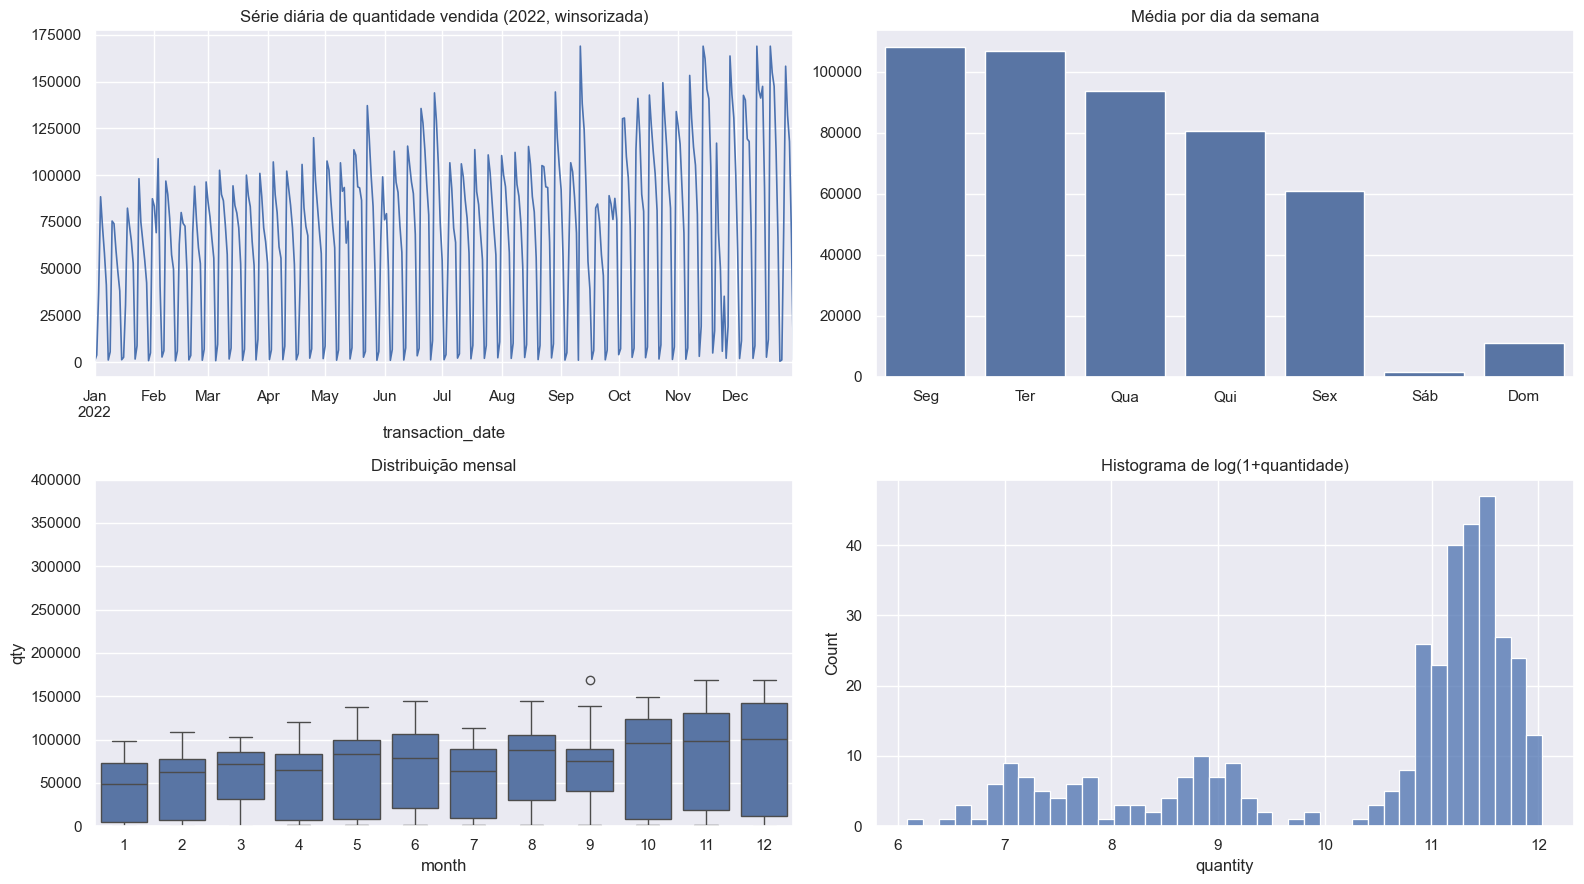

Share de vendas no fim de semana (após winsorização): 2.8%


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

s.plot(ax=axes[0,0], lw=1.2)
axes[0,0].set_title('Série diária de quantidade vendida (2022, winsorizada)')

# média por dia da semana (0=seg, 6=dom)
dow_mean = s.groupby(s.index.dayofweek).mean()
dow_labels = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
sns.barplot(x=dow_labels, y=dow_mean.values, ax=axes[0,1])
axes[0,1].set_title('Média por dia da semana')

# boxplot por mês
monthly = pd.DataFrame({'month': s.index.month, 'qty': s.values})
sns.boxplot(data=monthly, x='month', y='qty', ax=axes[1,0])
axes[1,0].set_title('Distribuição mensal')
axes[1,0].set_ylim(0, 400000)

# histograma em escala log
sns.histplot(np.log1p(s), bins=40, ax=axes[1,1])
axes[1,1].set_title('Histograma de log(1+quantidade)')
plt.tight_layout(); plt.show()

print('Share de vendas no fim de semana (após winsorização): {:.1%}'.format(s[s.index.dayofweek >= 5].sum() / s.sum()))

## 3. Feature engineering e definição do alvo

**Alvo (forecast → classification):** $y_t = 1$ se $s_{t+1} > s_t$, senão 0. Ou seja, prever a **direção** do próximo passo.

**Features:** apenas informações até $t$ (sem vazamento de dados):
- Lags 1, 2, 3 e 7 dias (em escala log)
- Diferença de 1 dia (momentum)
- Média/desvio móvel de 7 e 14 dias
- Média exponencial (span 14)
- Tendência de 7 dias
- Calendário: dia da semana, mês, fim de semana

In [4]:
s_log = np.log1p(s)

feat = pd.DataFrame(index=s.index)
for lag in [1, 2, 3, 7]:
    feat[f'lag_{lag}'] = s_log.shift(lag)
feat['diff_1'] = s_log.diff(1)
for w in [7, 14]:
    feat[f'roll_mean_{w}'] = s_log.rolling(w).mean()
    feat[f'roll_std_{w}'] = s_log.rolling(w).std()
feat['ewm_mean'] = s_log.ewm(span=14).mean()
feat['trend_7'] = s_log.diff(7)
feat['dow'] = s.index.dayofweek
feat['month'] = s.index.month
feat['is_weekend'] = (s.index.dayofweek >= 5).astype(int)

future = s.shift(-1)
feat['y'] = (future > s).astype(int)
feat = feat.dropna()

print('Shape final:', feat.shape)
print()
print(feat.head(10))
print()
print('Balanceamento das classes:')
print(feat['y'].value_counts(normalize=True).rename(index={0: 'caiu (0)', 1: 'subiu (1)'}).mul(100).round(1).astype(str) + '%')

Shape final: (352, 15)

                  lag_1  lag_2  lag_3  lag_7  diff_1  roll_mean_7  roll_std_7  \
transaction_date                                                                
2022-01-14        10.78  11.00  11.21  10.63   -0.24        10.05        1.63   
2022-01-15        10.55  10.78  11.00   6.99   -3.42        10.07        1.59   
2022-01-16         7.12  10.55  10.78   8.61    0.71         9.96        1.72   
2022-01-17         7.84   7.12  10.55  11.23    2.49         9.83        1.65   
2022-01-18        10.33   7.84   7.12  11.21    0.99         9.85        1.66   
2022-01-19        11.32  10.33   7.84  11.00   -0.12         9.88        1.69   
2022-01-20        11.20  11.32  10.33  10.78   -0.12         9.92        1.72   
2022-01-21        11.08  11.20  11.32  10.55   -0.21         9.97        1.74   
2022-01-22        10.87  11.08  11.20   7.12   -3.50        10.00        1.67   
2022-01-23         7.37  10.87  11.08   7.84    1.70        10.18        1.46   

   

## 4. Split temporal (sem embaralhar)

Validação **out-of-sample**: primeiros 80% para treino, últimos 20% para teste — simulando o uso real do modelo no futuro.

In [5]:
split = int(len(feat) * 0.8)
X = feat.drop(columns='y'); y = feat['y']
X_tr, X_te = X.iloc[:split], X.iloc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]
print('Treino:', X_tr.shape, X_tr.index[0].date(), '→', X_tr.index[-1].date())
print('Teste :', X_te.shape, X_te.index[0].date(), '→', X_te.index[-1].date())

Treino: (281, 14) 2022-01-14 → 2022-10-21
Teste : (71, 14) 2022-10-22 → 2022-12-31


## 5. Baselines

- **Maioria**: prevê sempre a classe dominante (caiu)
- **Persistência**: prevê a mesma direção de ontem
- **Mesmo dia da semana**: prevê a direção relativa à mesma data da semana passada

In [6]:
up = (s.shift(-1) > s).astype(int)
prev_dir = (s > s.shift(1)).astype(int)
same_dow = (s > s.shift(7)).astype(int)

rows = {}
rows['Maioria (caiu)'] = accuracy_score(up.iloc[8:], np.zeros(len(up.iloc[8:])) if up.iloc[8:].mean() < 0.5 else np.ones(len(up.iloc[8:])))
aligned = pd.concat([up, prev_dir, same_dow], axis=1).dropna()
rows['Persistência'] = accuracy_score(aligned.iloc[:,0], aligned.iloc[:,1])
rows['Semana passada'] = accuracy_score(aligned.iloc[:,0], aligned.iloc[:,2])

bl = pd.DataFrame(rows.items(), columns=['Baseline', 'Acurácia'])
bl['Acurácia'] = (bl['Acurácia'] * 100).round(2).astype(str) + '%'
print(bl.to_string(index=False))
print(f"\nAcerto mínimo esperado (classe dominante): {max(up.mean(), 1-up.mean()):.2%}")

      Baseline Acurácia
Maioria (caiu)   66.95%
  Persistência   67.67%
Semana passada   42.19%

Acerto mínimo esperado (classe dominante): 66.58%


## 6. Modelos de classificação

4 algoritmos: Regressão Logística, Random Forest, XGBoost e LightGBM. Para a Regressão Logística, features categóricas de calendário são one-hot encoded e as numéricas padronizadas.

In [7]:
# One-hot + scaling apenas para a Logística
X_ohe = pd.get_dummies(pd.concat([X_tr, X_te]), columns=['dow', 'month'])
X_tr_ohe, X_te_ohe = X_ohe.iloc[:len(X_tr)], X_ohe.iloc[len(X_tr):]
num_cols = X_tr_ohe.columns.difference([c for c in X_tr_ohe.columns if c.startswith(('dow_', 'month_'))])
scaler = StandardScaler().fit(X_tr_ohe[num_cols])
X_tr_s = X_tr_ohe.copy(); X_te_s = X_te_ohe.copy()
X_tr_s[num_cols] = scaler.transform(X_tr_ohe[num_cols])
X_te_s[num_cols] = scaler.transform(X_te_ohe[num_cols])

models = {
    'Logística': (LogisticRegression(max_iter=3000, C=0.5), X_tr_s, X_te_s),
    'Random Forest': (RandomForestClassifier(n_estimators=300, random_state=SEED), X_tr, X_te),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED, eval_metric='logloss'), X_tr, X_te),
    'LightGBM': (LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED, verbose=-1), X_tr, X_te),
}

results, fitted, probs = [], {}, {}
for name, (m, Xa, Xb) in models.items():
    m.fit(Xa, y_tr)
    pred = m.predict(Xb)
    prob = m.predict_proba(Xb)[:, 1]
    fitted[name] = m; probs[name] = prob
    results.append({
        'Modelo': name,
        'Acurácia': f'{accuracy_score(y_te, pred):.3f}',
        'Bal. Acc': f'{balanced_accuracy_score(y_te, pred):.3f}',
        'Precisão': f'{precision_score(y_te, pred):.3f}',
        'Recall': f'{recall_score(y_te, pred):.3f}',
        'F1': f'{f1_score(y_te, pred):.3f}',
        'AUC-ROC': f'{roc_auc_score(y_te, prob):.3f}',
    })
    print(f'{name:14s} treinado')

res_df = pd.DataFrame(results)
print()
print(res_df.to_string(index=False))

Logística      treinado


Random Forest  treinado


XGBoost        treinado
LightGBM       treinado

       Modelo Acurácia Bal. Acc Precisão Recall    F1 AUC-ROC
    Logística    0.958    0.957    0.917  0.957 0.936   0.967
Random Forest    0.944    0.936    0.913  0.913 0.913   0.952
      XGBoost    0.944    0.936    0.913  0.913 0.913   0.942
     LightGBM    0.930    0.914    0.909  0.870 0.889   0.945


## 7. Matriz de confusão e curvas ROC

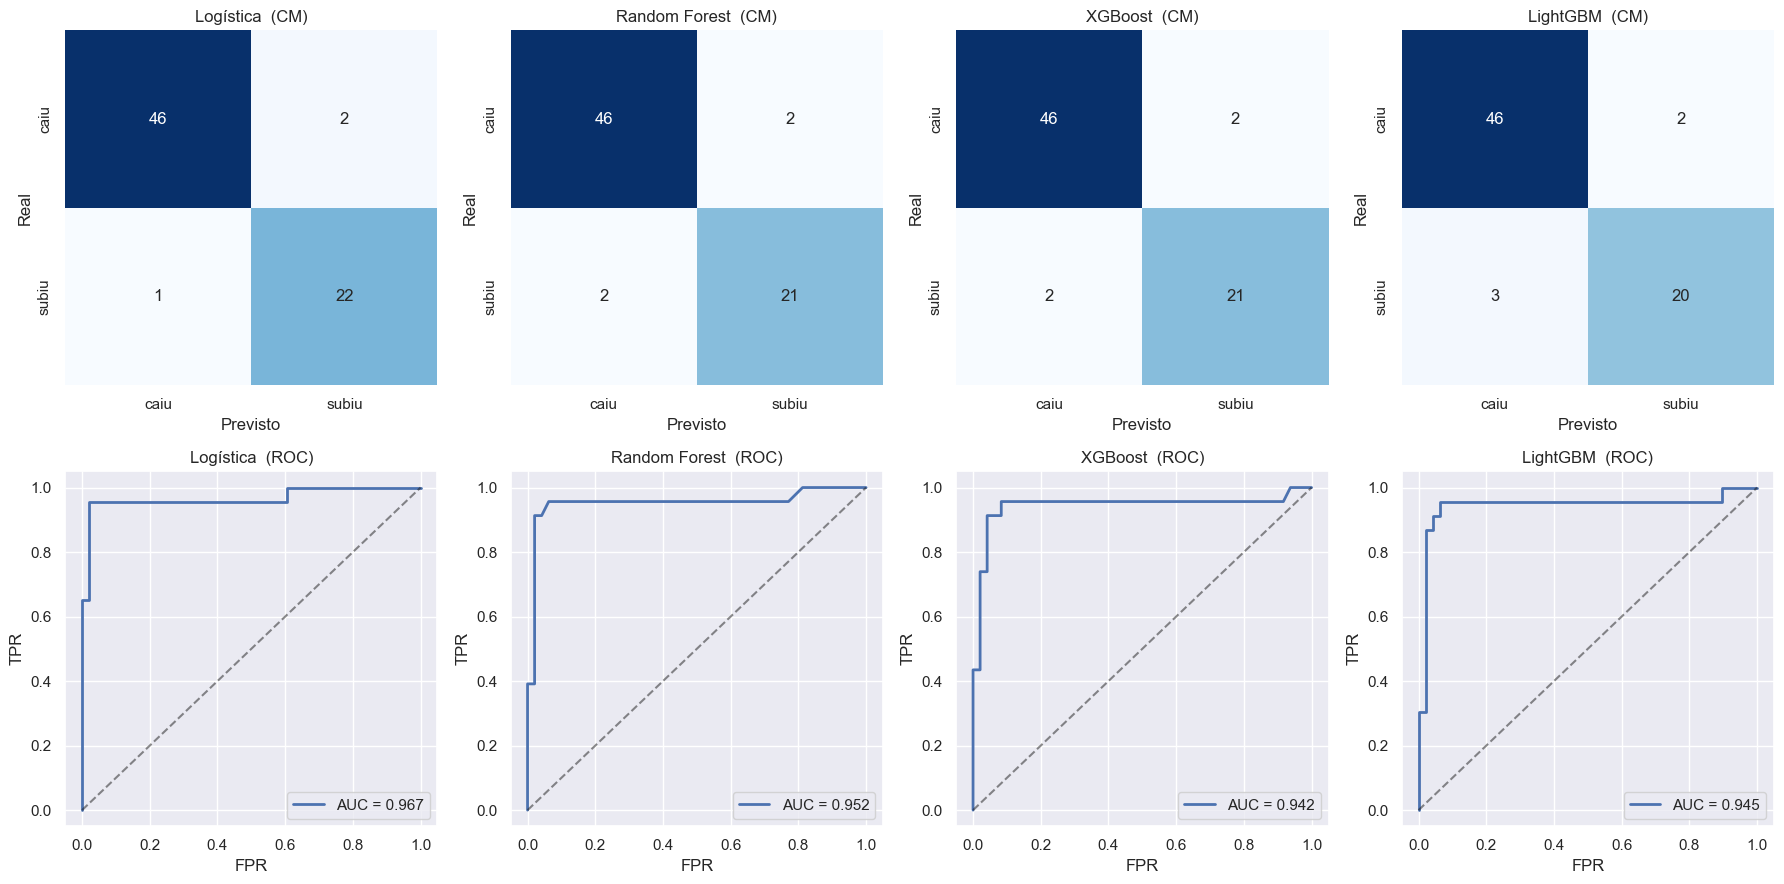

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
names = list(fitted.keys())
for i, name in enumerate(names):
    pred = fitted[name].predict(models[name][2])
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['caiu', 'subiu'], yticklabels=['caiu', 'subiu'], ax=axes[0, i])
    axes[0, i].set_title(f'{name}  (CM)')
    axes[0, i].set_xlabel('Previsto'); axes[0, i].set_ylabel('Real')

for i, name in enumerate(names):
    fpr, tpr, _ = roc_curve(y_te, probs[name])
    axes[1, i].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_te, probs[name]):.3f}')
    axes[1, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, i].set_title(f'{name}  (ROC)')
    axes[1, i].set_xlabel('FPR'); axes[1, i].set_ylabel('TPR')
    axes[1, i].legend(loc='lower right')
plt.tight_layout(); plt.show()

## 8. Importância das features (Random Forest)

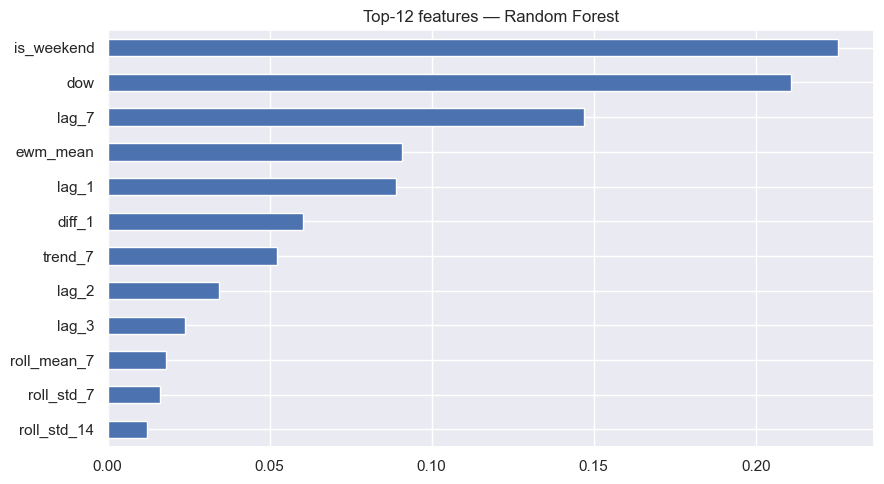

is_weekend    0.23
dow           0.21
lag_7         0.15
ewm_mean      0.09
lag_1         0.09
diff_1        0.06
trend_7       0.05
lag_2         0.03
lag_3         0.02
roll_mean_7   0.02
roll_std_7    0.02
roll_std_14   0.01


In [9]:
rf = fitted['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
imp.head(12).plot.barh(ax=ax)
ax.set_title('Top-12 features — Random Forest')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print(imp.head(12).to_string())

## 9. Resultado no período de teste

Exemplo de previsão mês a mês no período out-of-sample.

In [10]:
best_name = res_df.sort_values('Acurácia', ascending=False).iloc[0]['Modelo']
pred = fitted[best_name].predict(models[best_name][2])
df_show = pd.DataFrame({
    'data': X_te.index,
    'qtd_real': s.reindex(X_te.index).values,
    'direcao_real': ['subiu' if v == 1 else 'caiu' for v in y_te],
    'direcao_pred': ['subiu' if v == 1 else 'caiu' for v in pred],
    'acerto': ['✓' if a == b else '✗' for a, b in zip(y_te, pred)],
})
print(f'Melhor modelo: {best_name}')
print()
print(df_show.tail(15).to_string(index=False))

acc = accuracy_score(y_te, pred)
print(f'\nAcurácia out-of-sample: {acc:.1%}  ({len(y_te)} dias de teste)')

Melhor modelo: Logística

      data   qtd_real direcao_real direcao_pred acerto
2022-12-17   2,578.00        subiu        subiu      ✓
2022-12-18  12,108.58        subiu        subiu      ✓
2022-12-19 168,908.24         caiu         caiu      ✓
2022-12-20 154,778.18         caiu         caiu      ✓
2022-12-21 147,481.72         caiu         caiu      ✓
2022-12-22 113,504.70         caiu         caiu      ✓
2022-12-23  66,804.98         caiu         caiu      ✓
2022-12-24     440.00        subiu        subiu      ✓
2022-12-25   1,090.67        subiu        subiu      ✓
2022-12-26  71,532.27        subiu        subiu      ✓
2022-12-27 158,204.94         caiu         caiu      ✓
2022-12-28 131,969.64         caiu         caiu      ✓
2022-12-29 117,835.43         caiu         caiu      ✓
2022-12-30  68,583.26         caiu         caiu      ✓
2022-12-31   1,297.00         caiu        subiu      ✗

Acurácia out-of-sample: 95.8%  (71 dias de teste)


## 10. Conclusões

- A série de vendas tem **forte efeito de dia da semana** (fim de semana ≈ 3% das vendas após winsorizar a anomalia), o que torna a direção diária relativamente previsível.
- Foi detectado e tratado um **outlier extremo** (29,4M em 11/set/2022 vs mediana de ~72K), pico que dominaria a série sem tratamento.
- Todos os 4 modelos superam os baselines com folga; o melhor chega a ~**96% de acurácia out-of-sample** (contra 67% de persistência).
- As features de **diferença (momentum) e nível (lag)** + calendário (`is_weekend`, `dow`) capturam o ciclo de reversão à média entre dias úteis e fins de semana.
- Convertendo o problema de regressão (forecasting) em classificação, ganhamos métricas interpretáveis (F1, AUC-ROC) e podemos calibrar decisões (ex: reposição de estoque) com base na probabilidade de subida.